# 利率期限結構

回顧定價基礎公式，分母之利率 ($r$) 為重要的定價基礎，其扮演貨幣時間價值的角色。
$$
    V = \sum^{T}_{t=0} \frac{CF_t}{(1+r)^t}
$$

利率期限結構則是描述不同期限的零息利率所構成的曲線，折現因子、零息利率與遠期利率在數學上可相互推導。<br>
也就是知其一即可得其二，因此本套件在設計利率期限結構時，提供以下三種方法: 
1. `get_zcb`
2. `get_spot_rate`
3. `get_forward_rate`

再給定日期下，分別計算折現因子、零息與遠期利率。<br>
除此之外，在利率工程學中，常常以年化時間長度取代真實日期，因此也提供以下三種方法:
1. `get_zcb_tau`
2. `get_spot_rate_tau`
3. `get_forward_rate_tau`

再給定年化時間長度下，分別計算折現因子、零息與遠期利率。<br>

我們以一個水平利率期限結構 `FlatForward` 為舉例。

In [1]:
from valora.basic.term_structure import FlatForward
from valora.basic.date import Date
from valora import Compounding

r = 0.05
rf_date = Date(2026, 6, 22)
compound = Compounding.ANNUAL

curve = FlatForward(
    reference_date=rf_date,
    rate=r,
    compound=compound
)

繪製零息利率期限結構、折現因子期限結構、遠期利率期限結構


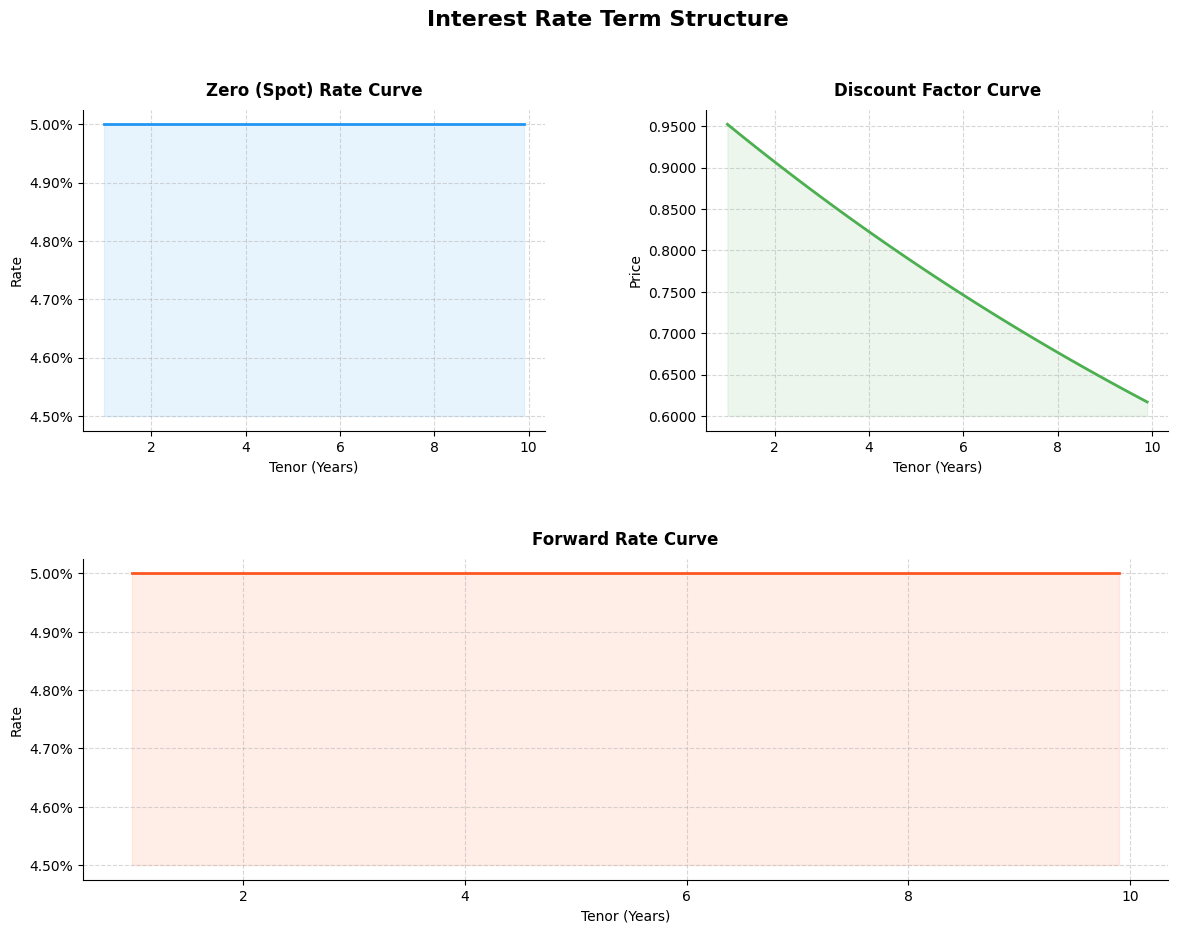

In [2]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import numpy as np

ts = np.arange(1, 10, 0.1)
rs = np.array([curve.get_spot_rate_tau(t, compound) for t in ts])
ds = np.array([curve.get_zcb_tau(0, t) for t in ts])
fs = np.array([curve.get_forward_rate_tau(t, t+5, compound) for t in ts])

fig = plt.figure(figsize=(14, 10))
fig.suptitle("Interest Rate Term Structure", fontsize=16, fontweight="bold", y=0.98)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])

STYLE = dict(linewidth=2)

def style_ax(ax, title, xlabel, ylabel, color):
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"{x:.2%}")
        if ylabel != "Price"
        else plt.FuncFormatter(lambda x, _: f"{x:.4f}")
    )
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.spines[["top", "right"]].set_visible(False)

ax1.plot(ts, rs, color="#2196F3", **STYLE)
ax1.fill_between(ts, rs, 0.045, alpha=0.1, color="#2196F3")
style_ax(ax1, "Zero (Spot) Rate Curve", "Tenor (Years)", "Rate", "#2196F3")

ax2.plot(ts, ds, color="#4CAF50", **STYLE)
ax2.fill_between(ts, ds, 0.6, alpha=0.1, color="#4CAF50")
style_ax(ax2, "Discount Factor Curve", "Tenor (Years)", "Price", "#4CAF50")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.4f}"))

ax3.plot(ts, fs, color="#FF5722", **STYLE)
ax3.fill_between(ts, fs, 0.045, alpha=0.1, color="#FF5722")
style_ax(ax3, "Forward Rate Curve", "Tenor (Years)", "Rate", "#FF5722")

plt.show()

## 零息公債殖利率曲線

水平利率期限結構過於美好，現實利率期限結構存在倒掛、正掛等樣態。<br>
部份官方機構會公告零息利率點，我們可通過 `InterpolatedZeroCurve` 選定插補法建立期限結構。<br>
`InterpolatedZeroCurve` 同樣提供上述 6 種方法，方便使用者快速計算零息、遠期利率與折現因子。<br>

我們取用 2020-7-13 當天台灣櫃買中心公告的零息公債利率點，以此建立期限結構。<br>
| 年期 | 利率(%) |
|---|---|
|0.25|0.2884|
|0.5|0.2799|
|1|0.2602|
|2|0.2471|
|3|0.3020|
|5|0.3684|
|7|0.4399|
|8|0.4553|
|10|0.4571|
|15|0.5447|
|20|0.5763|
|30|0.6366|

In [3]:
from valora.basic.term_structure import InterpolatedZeroCurve
from valora.function.interpolator import LinearInterpolator, CubicSplineInterpolator

tenors = [0.25, 0.5, 1, 2, 3, 5, 7, 8, 10, 15, 20, 30]
zrates = np.array([
    0.2884, 0.2799, 0.2602, 0.2471, 0.3020, 0.3684, 0.4399, 0.4553, 0.4571,
    0.5447, 0.5763, 0.6366
    ])/100

curve = InterpolatedZeroCurve(
    tenors=tenors,
    zrates=zrates,
    interpator=CubicSplineInterpolator(),
    reference_date=rf_date,
    compound=compound,
)

繪製零息利率期限結構、折現因子期限結構、遠期利率期限結構

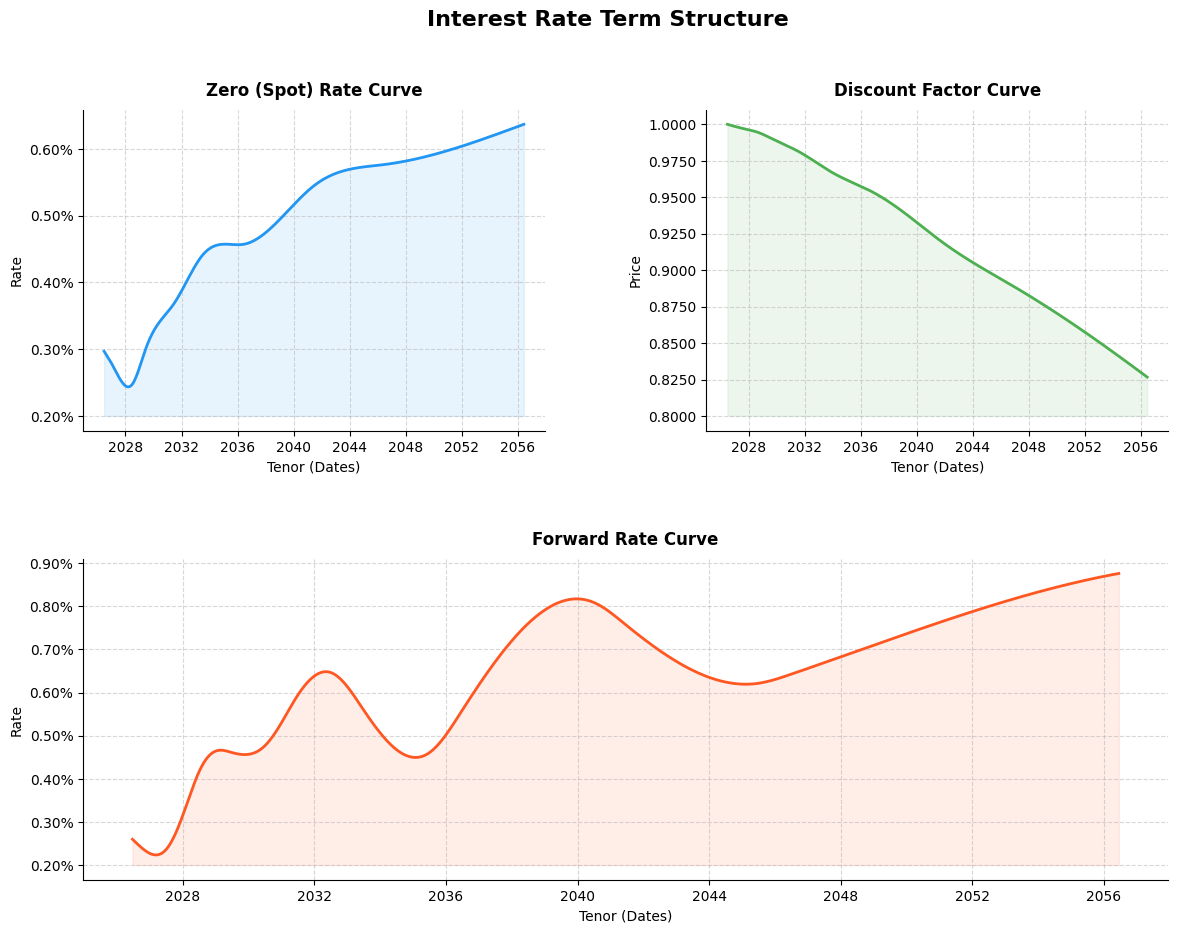

In [4]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import numpy as np

from valora.basic.daycount import Act365Fixed
from valora.basic.date import Period
from valora import PeriodType

daycount = Act365Fixed

dts = [rf_date + t for t in range(1, 365*30)]
rs = np.array([curve.get_spot_rate(daycount, dt, compound) for dt in dts])
ds = np.array([curve.get_zcb(daycount, rf_date, dt) for dt in dts])
fs = np.array(
    [
        curve.get_forward_rate(daycount, dt, dt + Period(PeriodType.YEARLY, 1), compound)
        for dt in dts
    ]
)

dts = [dt.date for dt in dts]

fig = plt.figure(figsize=(14, 10))
fig.suptitle("Interest Rate Term Structure", fontsize=16, fontweight="bold", y=0.98)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])

STYLE = dict(linewidth=2)


def style_ax(ax, title, xlabel, ylabel, color):
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"{x:.2%}")
        if ylabel != "Price"
        else plt.FuncFormatter(lambda x, _: f"{x:.4f}")
    )
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.spines[["top", "right"]].set_visible(False)


ax1.plot(dts, rs, color="#2196F3", **STYLE)
ax1.fill_between(dts, rs, 0.2/100, alpha=0.1, color="#2196F3")
style_ax(ax1, "Zero (Spot) Rate Curve", "Tenor (Dates)", "Rate", "#2196F3")

ax2.plot(dts, ds, color="#4CAF50", **STYLE)
ax2.fill_between(dts, ds, 0.8, alpha=0.1, color="#4CAF50")
style_ax(ax2, "Discount Factor Curve", "Tenor (Dates)", "Price", "#4CAF50")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.4f}"))

ax3.plot(dts, fs, color="#FF5722", **STYLE)
ax3.fill_between(dts, fs, 0.2/100, alpha=0.1, color="#FF5722")
style_ax(ax3, "Forward Rate Curve", "Tenor (Dates)", "Rate", "#FF5722")

plt.show()

## 拔靴法: 由利率商品生成期限結構


許多指標利率並不具有公告的零息利率，因此需要使用利率商品拔靴出期限結構。<br>
或是官方僅有公告票面殖利率 (Par Yield)，因此也需要拔靴為零息結構。<br>

我們以 FED 公告之 Par yield 報價 (2026/6/1)，來拔靴出美國公債利率期限結構。<br>
|年期|利率(%)|
|---|---|
|1mo|3.72|
|2mo|3.73|
|3mo|3.78|
|4mo|3.80|
|6mo|3.79|
|1Y|3.83|
|2Y|4.05|
|3Y|4.09|
|5Y|4.18|
|7Y|4.32|
|10Y|4.47|
|20Y|4.99|
|30Y|4.99|

考量美國公債一年內商品皆為到期付息，且一年以上都是半年付息一次。<br>

In [5]:
from valora.function.bootstrapper import BootstrapEngine, ParYieldHelper
from valora.function.interpolator import LinearInterpolator
from valora.basic.date import Period, Date
from valora import PeriodType, Frequency

rdate = Date(2026, 6, 1)

helpers = [
    ParYieldHelper(0.0372, Period(PeriodType.MONTHLY, 1), Frequency.ONCE, rdate),
    ParYieldHelper(0.0373, Period(PeriodType.MONTHLY, 2), Frequency.ONCE, rdate),
    ParYieldHelper(0.0378, Period(PeriodType.MONTHLY, 3), Frequency.ONCE, rdate),
    ParYieldHelper(0.038, Period(PeriodType.MONTHLY, 4), Frequency.ONCE, rdate),
    ParYieldHelper(0.0379, Period(PeriodType.MONTHLY, 6), Frequency.ONCE, rdate),
    ParYieldHelper(0.0383, Period(PeriodType.YEARLY, 1), Frequency.SEMIANNUAL, rdate),
    ParYieldHelper(0.0405, Period(PeriodType.YEARLY, 2), Frequency.SEMIANNUAL, rdate),
    ParYieldHelper(0.0409, Period(PeriodType.YEARLY, 3), Frequency.SEMIANNUAL, rdate),
    ParYieldHelper(0.0418, Period(PeriodType.YEARLY, 5), Frequency.SEMIANNUAL, rdate),
    ParYieldHelper(0.0432, Period(PeriodType.YEARLY, 7), Frequency.SEMIANNUAL, rdate),
    ParYieldHelper(0.0447, Period(PeriodType.YEARLY, 10), Frequency.SEMIANNUAL, rdate),
    ParYieldHelper(0.0499, Period(PeriodType.YEARLY, 20), Frequency.SEMIANNUAL, rdate),
    ParYieldHelper(0.0499, Period(PeriodType.YEARLY, 30), Frequency.SEMIANNUAL, rdate),
]

engine = BootstrapEngine(rdate, helpers, LinearInterpolator())
curve = engine.run()

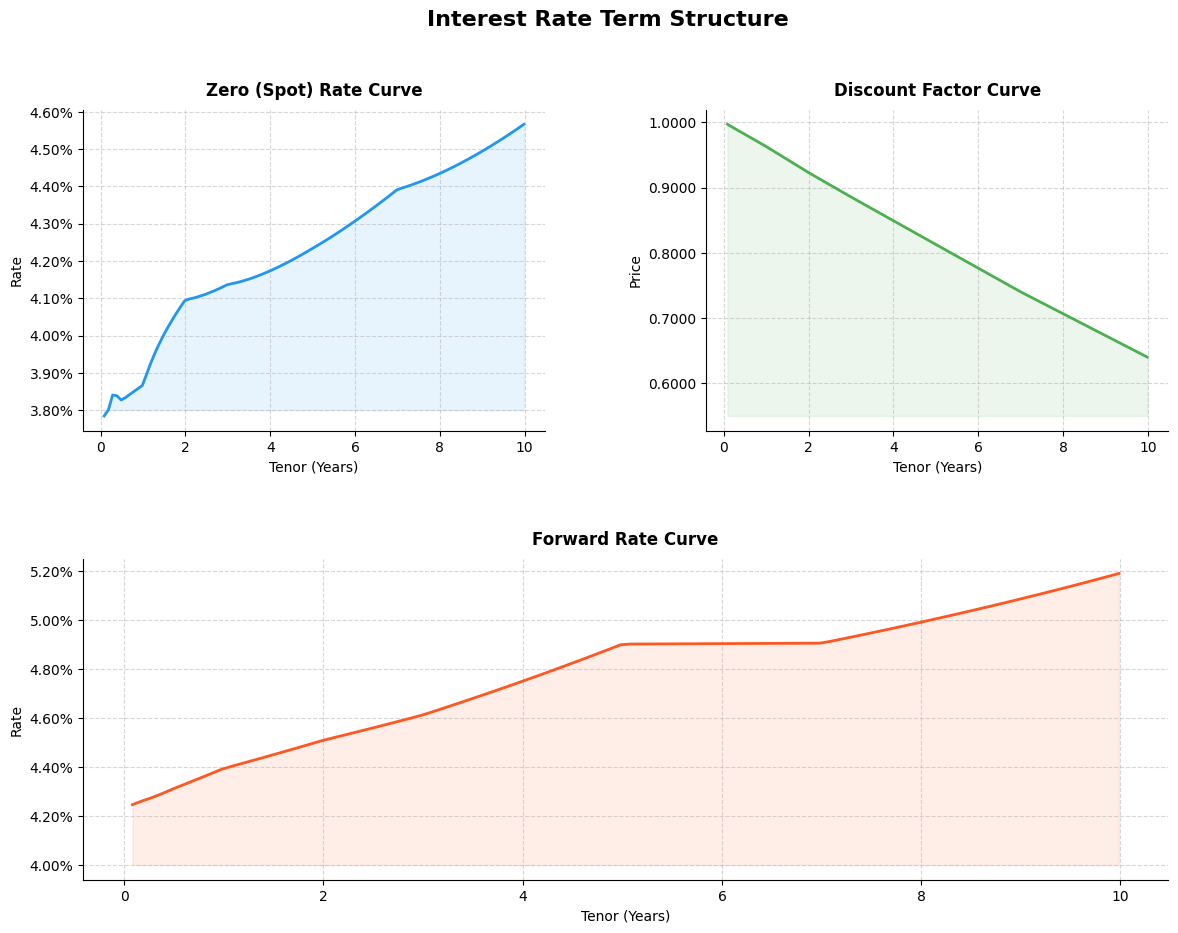

In [6]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import numpy as np

ts = np.arange(0.08333, 10, 0.1)
rs = np.array([curve.get_spot_rate_tau(t, compound) for t in ts])
ds = np.array([curve.get_zcb_tau(0, t) for t in ts])
fs = np.array([curve.get_forward_rate_tau(t, t+5, compound) for t in ts])

fig = plt.figure(figsize=(14, 10))
fig.suptitle("Interest Rate Term Structure", fontsize=16, fontweight="bold", y=0.98)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])

STYLE = dict(linewidth=2)

def style_ax(ax, title, xlabel, ylabel, color):
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"{x:.2%}")
        if ylabel != "Price"
        else plt.FuncFormatter(lambda x, _: f"{x:.4f}")
    )
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.spines[["top", "right"]].set_visible(False)

ax1.plot(ts, rs, color="#2196F3", **STYLE)
ax1.fill_between(ts, rs, 0.038, alpha=0.1, color="#2196F3")
style_ax(ax1, "Zero (Spot) Rate Curve", "Tenor (Years)", "Rate", "#2196F3")

ax2.plot(ts, ds, color="#4CAF50", **STYLE)
ax2.fill_between(ts, ds, 0.55, alpha=0.1, color="#4CAF50")
style_ax(ax2, "Discount Factor Curve", "Tenor (Years)", "Price", "#4CAF50")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.4f}"))

ax3.plot(ts, fs, color="#FF5722", **STYLE)
ax3.fill_between(ts, fs, 0.04, alpha=0.1, color="#FF5722")
style_ax(ax3, "Forward Rate Curve", "Tenor (Years)", "Rate", "#FF5722")

plt.show()

對於一些較特殊的指標利率，由於缺乏官方機構統計的 par yield 資料，因此交易者往往只能使用相關利率衍生物來拔靴。<br>
我們以 SOFR 為舉例，常見的衍生物有 futures, OIS 兩者，搭配 SOFR 公告值最為 ON 的報價，我們可以拔出一條 SOFR 曲線。<br>
請注意 SOFR 在拔靴時，要使用交易量較高的商品，以確保正確性。<br>

我們以 2026/6/18 觀察到的 SOFR 利率、期貨與 OIS 報價拔靴，詳細商品請見下表: <br>

|商品種類|報價|起始日|到期日|計息慣例|付息頻率|
|---|---|---|---|---|---|
|ON|3.62%|2026-6-18|2026-6-19|Act360|到期給付|
|Futures|96.07|2026-9-16|2026-12-16|Act360|到期支付|
|Futures|95.92|2026-12-16|2027-3-16|Act360|到期支付|
|Futures|95.865|2027-3-16|2027-6-16|Act360|到期支付|
|Futures|95.93|2027-6-16|2027-9-16|Act360|到期支付|
|OIS|4.06%|2027-6-18|2Y| - | 固定腿: 每年/浮動腿: 每年|
|OIS|4.05%|2027-6-18|3Y| - | 固定腿: 每年/浮動腿: 每年|
|OIS|4.02%|2027-6-18|4Y| - | 固定腿: 每年/浮動腿: 每年|
|OIS|4.01%|2027-6-18|5Y| - | 固定腿: 每年/浮動腿: 每年|
|OIS|4.02%|2027-6-18|6Y| - | 固定腿: 每年/浮動腿: 每年|
|OIS|4.03%|2027-6-18|7Y| - | 固定腿: 每年/浮動腿: 每年|
|OIS|4.05%|2027-6-18|8Y| - | 固定腿: 每年/浮動腿: 每年|
|OIS|4.08%|2027-6-18|9Y| - | 固定腿: 每年/浮動腿: 每年|
|OIS|4.10%|2027-6-18|10Y| - | 固定腿: 每半年/浮動腿: 每年|
|OIS|4.23%|2027-6-18|15Y| - | 固定腿: 每半年/浮動腿: 每年|
|OIS|4.29%|2027-6-18|20Y| - | 固定腿: 每半年/浮動腿: 每年|
|OIS|4.24%|2027-6-18|30Y| - | 固定腿: 每半年/浮動腿: 每年|

請注意這裡的 OIS 付息頻率為假設，因缺乏資料。

In [20]:
from valora.function.bootstrapper import FuturesHelper, OisHelper
from valora.basic.daycount import Act360
from valora.function.interpolator import LogLinearInterpolator

rdate = Date(2026, 6, 18)

helpers = [
    ParYieldHelper(3.62/100, Period(PeriodType.DAILY, 1), Frequency.ONCE, rdate, Act360()),
    FuturesHelper(96.07, rdate, Date(2026, 9, 16), Date(2026, 12, 16), Act360, 0),
    FuturesHelper(95.92, rdate, Date(2026, 12, 16), Date(2027, 3, 16), Act360, 0),
    FuturesHelper(95.865, rdate, Date(2027, 3, 16), Date(2027, 6, 16), Act360, 0),
    FuturesHelper(95.93, rdate, Date(2027, 6, 16), Date(2027, 9, 16), Act360, 0),
    OisHelper(4.06/100, rdate, Period(PeriodType.YEARLY, 2), Frequency.ANNUAL, Frequency.ANNUAL),
    OisHelper(4.05/100, rdate, Period(PeriodType.YEARLY, 3), Frequency.ANNUAL, Frequency.ANNUAL),
    OisHelper(4.02/100, rdate, Period(PeriodType.YEARLY, 4), Frequency.ANNUAL, Frequency.ANNUAL),
    OisHelper(4.01/100, rdate, Period(PeriodType.YEARLY, 5), Frequency.ANNUAL, Frequency.ANNUAL),
    OisHelper(4.02/100, rdate, Period(PeriodType.YEARLY, 6), Frequency.ANNUAL, Frequency.ANNUAL),
    OisHelper(4.03/100, rdate, Period(PeriodType.YEARLY, 7), Frequency.ANNUAL, Frequency.ANNUAL),
    OisHelper(4.05/100, rdate, Period(PeriodType.YEARLY, 8), Frequency.ANNUAL, Frequency.ANNUAL),
    OisHelper(4.08/100, rdate, Period(PeriodType.YEARLY, 9), Frequency.ANNUAL, Frequency.ANNUAL),
    OisHelper(4.10/100, rdate, Period(PeriodType.YEARLY, 10), Frequency.SEMIANNUAL, Frequency.ANNUAL),
    OisHelper(4.23/100, rdate, Period(PeriodType.YEARLY, 15), Frequency.SEMIANNUAL, Frequency.ANNUAL),
    OisHelper(4.29/100, rdate, Period(PeriodType.YEARLY, 20), Frequency.SEMIANNUAL, Frequency.ANNUAL),
    OisHelper(4.24/100, rdate, Period(PeriodType.YEARLY, 30), Frequency.SEMIANNUAL, Frequency.ANNUAL),
]

engine = BootstrapEngine(rdate, helpers, LogLinearInterpolator())
curve = engine.run()

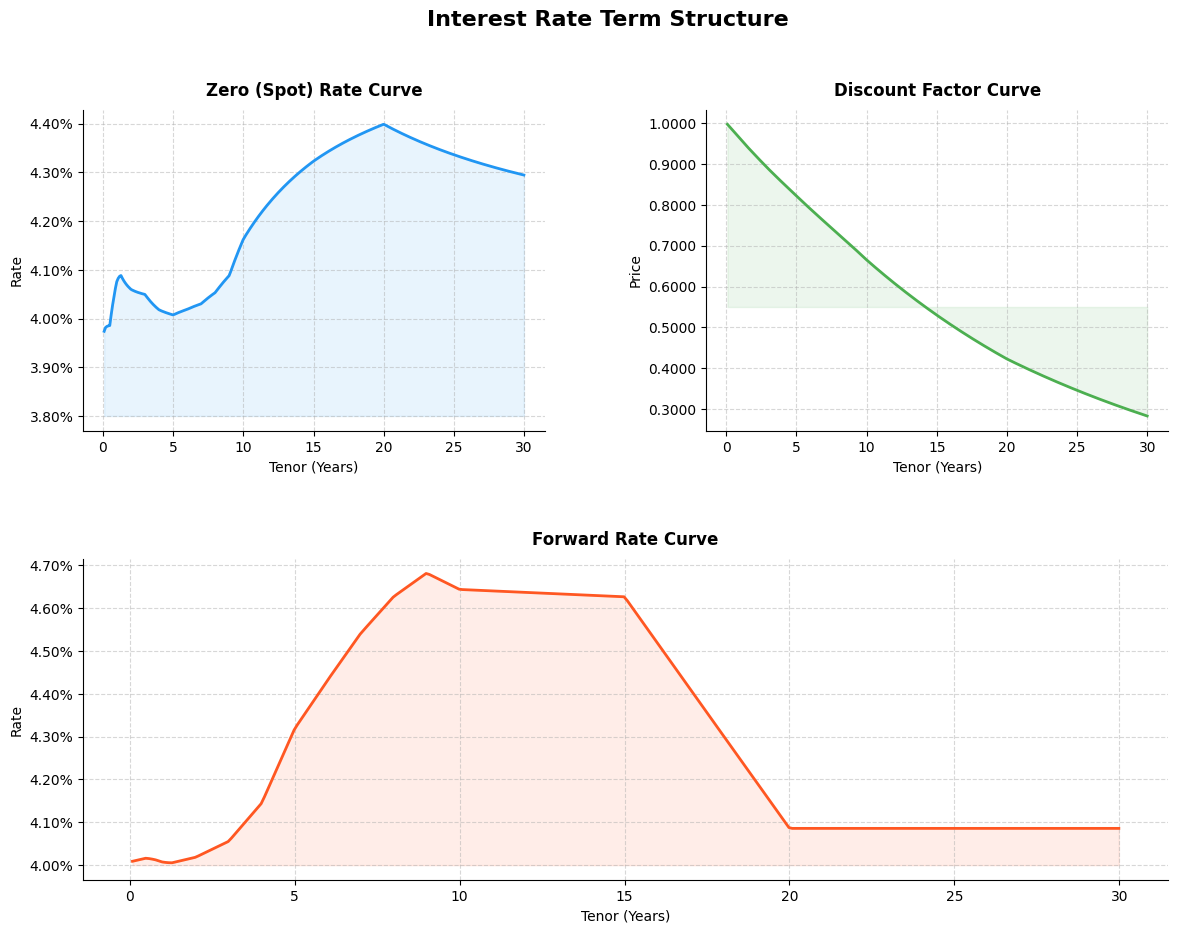

In [21]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import numpy as np

ts = np.arange(0.0833, 30, 0.1)
rs = np.array([curve.get_spot_rate_tau(t, compound) for t in ts])
ds = np.array([curve.get_zcb_tau(0, t) for t in ts])
fs = np.array([curve.get_forward_rate_tau(t, t+5, compound) for t in ts])

fig = plt.figure(figsize=(14, 10))
fig.suptitle("Interest Rate Term Structure", fontsize=16, fontweight="bold", y=0.98)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])

STYLE = dict(linewidth=2)

def style_ax(ax, title, xlabel, ylabel, color):
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"{x:.2%}")
        if ylabel != "Price"
        else plt.FuncFormatter(lambda x, _: f"{x:.4f}")
    )
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.spines[["top", "right"]].set_visible(False)

ax1.plot(ts, rs, color="#2196F3", **STYLE)
ax1.fill_between(ts, rs, 0.038, alpha=0.1, color="#2196F3")
style_ax(ax1, "Zero (Spot) Rate Curve", "Tenor (Years)", "Rate", "#2196F3")

ax2.plot(ts, ds, color="#4CAF50", **STYLE)
ax2.fill_between(ts, ds, 0.55, alpha=0.1, color="#4CAF50")
style_ax(ax2, "Discount Factor Curve", "Tenor (Years)", "Price", "#4CAF50")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.4f}"))

ax3.plot(ts, fs, color="#FF5722", **STYLE)
ax3.fill_between(ts, fs, 0.04, alpha=0.1, color="#FF5722")
style_ax(ax3, "Forward Rate Curve", "Tenor (Years)", "Rate", "#FF5722")

plt.show()